# ACME v4.1

Running all FM216 experiments with ACME-Lite (Hard Clipping)...

=== Quadratic cond=10 ===
  Trial 1/3
    ACME-Lite: 1785 iterations
    Adam: 1037 iterations
    SGDM: 156 iterations
    RMSprop: 2500 iterations
  Trial 2/3
    ACME-Lite: 1300 iterations
    Adam: 731 iterations
    SGDM: 159 iterations
    RMSprop: 559 iterations
  Trial 3/3
    ACME-Lite: 1449 iterations
    Adam: 1164 iterations
    SGDM: 163 iterations
    RMSprop: 2500 iterations


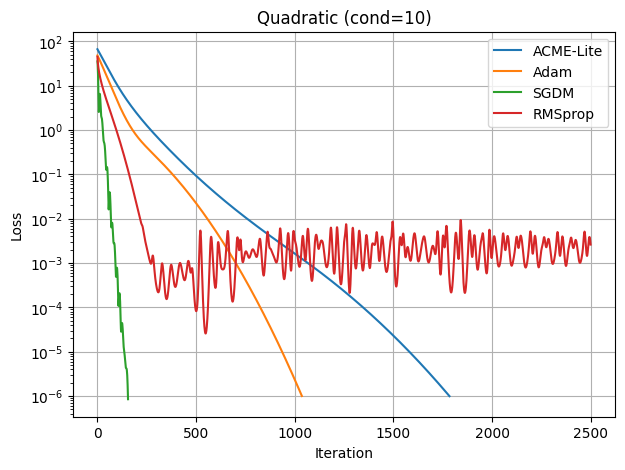


=== Quadratic cond=100 ===
  Trial 1/3
    ACME-Lite: 2500 iterations
    Adam: 2500 iterations
    SGDM: 178 iterations
    RMSprop: 2500 iterations
  Trial 2/3
    ACME-Lite: 2500 iterations
    Adam: 1359 iterations
    SGDM: 182 iterations
    RMSprop: 2500 iterations
  Trial 3/3
    ACME-Lite: 2500 iterations
    Adam: 2500 iterations
    SGDM: 185 iterations
    RMSprop: 2500 iterations


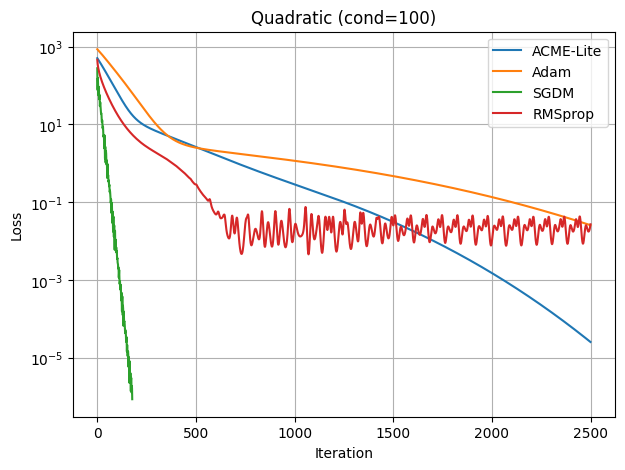


=== Rosenbrock Function ===
  Trial 1/3
    ACME-Lite: 5000 iterations
    Adam: 5000 iterations
    SGDM: 837 iterations
    RMSprop: 5000 iterations
  Trial 2/3
    ACME-Lite: 5000 iterations
    Adam: 5000 iterations
    SGDM: 837 iterations
    RMSprop: 5000 iterations
  Trial 3/3
    ACME-Lite: 5000 iterations
    Adam: 5000 iterations
    SGDM: 837 iterations
    RMSprop: 5000 iterations


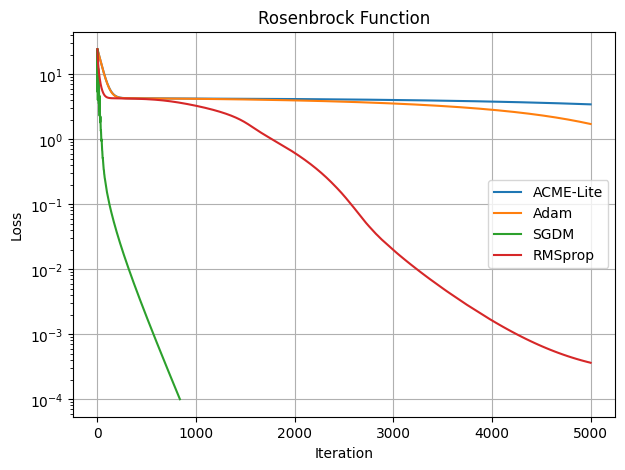


=== MNIST Experiment ===

Optimizer: ACME-Lite
  Epoch 01/20 | loss=0.4389 | acc=0.9341 | time=3.44s
  Epoch 02/20 | loss=0.1942 | acc=0.9525 | time=3.51s
  Epoch 03/20 | loss=0.1418 | acc=0.9608 | time=3.36s
  Epoch 04/20 | loss=0.1118 | acc=0.9670 | time=3.37s
  Epoch 05/20 | loss=0.0913 | acc=0.9687 | time=3.39s
  Epoch 06/20 | loss=0.0760 | acc=0.9700 | time=3.35s
  Epoch 07/20 | loss=0.0645 | acc=0.9713 | time=3.76s
  Epoch 08/20 | loss=0.0556 | acc=0.9729 | time=3.44s
  Epoch 09/20 | loss=0.0476 | acc=0.9765 | time=3.89s
  Epoch 10/20 | loss=0.0409 | acc=0.9767 | time=3.65s
  Epoch 11/20 | loss=0.0354 | acc=0.9736 | time=3.42s
  Epoch 12/20 | loss=0.0309 | acc=0.9763 | time=3.27s
  Epoch 13/20 | loss=0.0261 | acc=0.9782 | time=3.29s
  Epoch 14/20 | loss=0.0221 | acc=0.9771 | time=3.28s
  Epoch 15/20 | loss=0.0192 | acc=0.9779 | time=3.29s
  Epoch 16/20 | loss=0.0170 | acc=0.9789 | time=3.28s
  Epoch 17/20 | loss=0.0143 | acc=0.9777 | time=3.30s
  Epoch 18/20 | loss=0.0126 | acc=

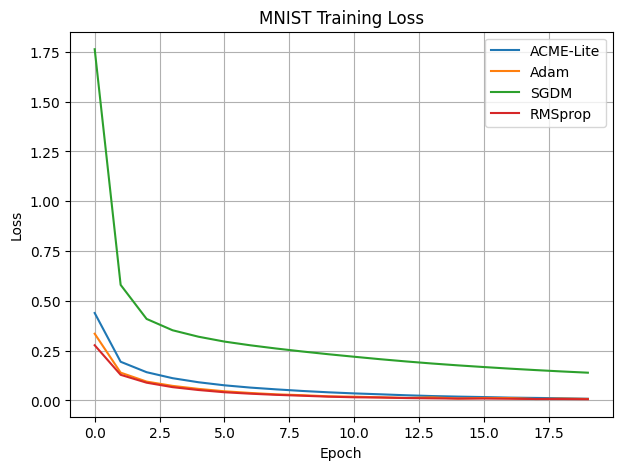

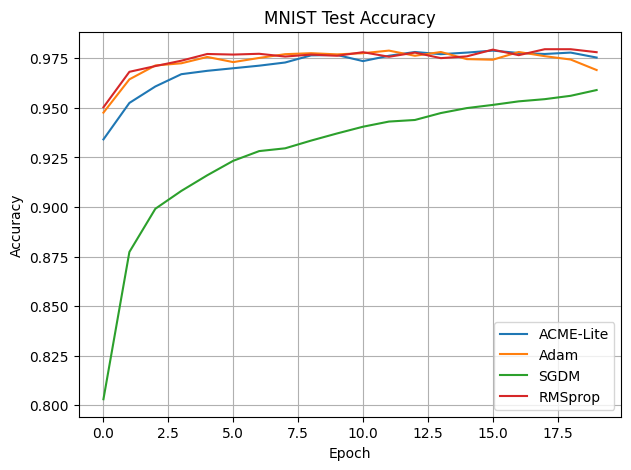


All experiments completed.


In [1]:
# ================================================================
# FM216 PROJECT – FINAL EXPERIMENT SUITE WITH ACME-LITE (HARD CLIP)
# ================================================================

import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7, 5)

# ================================================================
# Device + Seed
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)



# ================================================================
#  ACME-Lite Optimizer (Adam + Kurtosis Scaling + HARD CLIPPING)
# ================================================================
class ACME_Lite(torch.optim.Optimizer):
    """
    ACME-Lite with Fix #1 (HARD CLIPPING of Kurtosis)

    Step scaling:
        K_clipped = clamp(K_t, max=kurtosis_max)
        s_t = 1 / (1 + lambda_k * K_clipped)

    Final update:
        theta_{t+1} = theta_t - lr * s_t * m_hat / (sqrt(v_hat) + eps)
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        beta4=None,           # if None → use beta2
        lambda_k=0.1,         # strength of kurtosis penalty
        kurtosis_max=10.0,    # HARD CLIP recommended
        eps=1e-8,
    ):
        if beta4 is None:
            beta4 = betas[1]  # match Adam's v_t EMA rate

        defaults = dict(
            lr=lr,
            betas=betas,
            beta4=beta4,
            lambda_k=lambda_k,
            kurtosis_max=kurtosis_max,
            eps=eps,
        )
        super().__init__(params, defaults)


    @torch.no_grad()
    def step(self, closure=None):

        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:

            lr = group["lr"]
            beta1, beta2 = group["betas"]
            beta4 = group["beta4"]
            lambda_k = group["lambda_k"]
            kurtosis_max = group["kurtosis_max"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["E4"] = torch.zeros_like(p.data)

                m = state["m"]
                v = state["v"]
                E4 = state["E4"]

                state["step"] += 1
                t = state["step"]

                # --- Standard Adam ---
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # --- New 4th moment ---
                g4 = grad.pow(4)
                E4.mul_(beta4).add_(g4, alpha=1 - beta4)

                # Bias correction
                m_hat = m / (1 - beta1**t)
                v_hat = v / (1 - beta2**t)

                # --- Kurtosis calculation ---
                K_t = E4 / (v_hat.pow(2) + eps)

                # --- Fix #1: HARD CLIPPING ---
                K_clipped = torch.clamp(K_t, max=kurtosis_max)

                # Step scaling
                s_t = 1.0 / (1.0 + lambda_k * K_clipped)

                # Final ACME-Lite update
                denom = torch.sqrt(v_hat) + eps
                step = lr * s_t * (m_hat / denom)

                p.data.add_(-step)

        return loss




# ================================================================
# Quadratic Helpers
# ================================================================
def make_spd_matrix(dim=20, cond=10):
    """ Generate SPD matrix with given condition number. """
    Q, _ = np.linalg.qr(np.random.randn(dim, dim))
    eigs = np.linspace(1, cond, dim)
    return Q @ np.diag(eigs) @ Q.T


# ================================================================
# Quadratic Runner
# ================================================================
def run_quadratic(cond, dim=20, trials=3, max_iter=2500, tol=1e-6):

    print(f"\n=== Quadratic cond={cond} ===")

    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=1e-2, lambda_k=0.2),
        "Adam":      lambda params: torch.optim.Adam(params, lr=1e-2),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=1e-2, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=1e-2),
    }

    def f_quad(x, Q):
        return 0.5 * (x @ Q @ x)

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")

        Q_np = make_spd_matrix(dim, cond)
        Q = torch.tensor(Q_np, dtype=torch.float32, device=device)

        for name, opt_ctor in OPTS.items():

            x = torch.randn(dim, device=device, requires_grad=True)
            opt = opt_ctor([x])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_quad(x, Q)
                losses.append(loss.item())
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            logs[name].append(losses)
            print(f"    {name}: {len(losses)} iterations")

    # Plot (trial 1)
    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(f"Quadratic (cond={cond})")
    plt.grid(True)
    plt.legend()
    plt.show()

    return logs




# ================================================================
# Rosenbrock Runner
# ================================================================
def run_rosenbrock(max_iter=5000, tol=1e-4, trials=3):

    print("\n=== Rosenbrock Function ===")

    def f_rosen(theta):
        x, y = theta[0], theta[1]
        return (1 - x)**2 + 100 * (y - x**2)**2

    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=1e-3, lambda_k=0.2),
        "Adam":      lambda params: torch.optim.Adam(params, lr=1e-3),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=1e-3, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=1e-3),
    }

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")

        for name, opt_ctor in OPTS.items():

            theta = torch.tensor([-1.2, 1.0], device=device, requires_grad=True)
            opt = opt_ctor([theta])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_rosen(theta)
                losses.append(loss.item())
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            logs[name].append(losses)
            print(f"    {name}: {len(losses)} iterations")

    # Plot
    for name in OPTS:
        plt.plot(logs[name][0], label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Rosenbrock Function")
    plt.grid(True)
    plt.legend()
    plt.show()

    return logs




# ================================================================
# MNIST Runner (MLP)
# ================================================================
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def mnist_loaders(batch=64):
    transform = transforms.ToTensor()
    train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch, shuffle=False)
    return train_loader, test_loader



def train_one_epoch(model, opt, loader):
    model.train()
    total = 0
    loss_sum = 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits,y)
        loss.backward()
        opt.step()
        loss_sum += loss.item()*x.size(0)
        total    += x.size(0)
    return loss_sum/total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct=0
    total=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(1)
        correct += (preds==y).sum().item()
        total   += y.size(0)
    return correct/total



def run_mnist(epochs=20):

    print("\n=== MNIST Experiment ===")

    train_loader, test_loader = mnist_loaders()

    OPTS = {
        "ACME-Lite": lambda params: ACME_Lite(params, lr=5e-4, lambda_k=0.2),
        "Adam":      lambda params: torch.optim.Adam(params, lr=1e-3),
        "SGDM":      lambda params: torch.optim.SGD(params, lr=1e-3, momentum=0.9),
        "RMSprop":   lambda params: torch.optim.RMSprop(params, lr=1e-3),
    }

    results = {}

    for name,opt_ctor in OPTS.items():
        print(f"\nOptimizer: {name}")
        set_seed(BASE_SEED + 100)

        model = MNISTNet().to(device)
        opt   = opt_ctor(model.parameters())

        train_losses=[]
        test_accs=[]

        for epoch in range(1,epochs+1):
            t0=time.time()

            train_loss = train_one_epoch(model,opt,train_loader)
            acc = evaluate(model,test_loader)
            dt = time.time()-t0

            print(f"  Epoch {epoch:02d}/{epochs} | "
                  f"loss={train_loss:.4f} | acc={acc:.4f} | time={dt:.2f}s")

            train_losses.append(train_loss)
            test_accs.append(acc)

        results[name] = {
            "train_losses": np.array(train_losses),
            "test_accs"   : np.array(test_accs),
        }

    # Plot Loss
    plt.figure()
    for name in results:
        plt.plot(results[name]["train_losses"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MNIST Training Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot Accuracy
    plt.figure()
    for name in results:
        plt.plot(results[name]["test_accs"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("MNIST Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    return results




# ================================================================
# RUN ALL EXPERIMENTS
# ================================================================
print("Running all FM216 experiments with ACME-Lite (Hard Clipping)...")

quad10_logs  = run_quadratic(cond=10)
quad100_logs = run_quadratic(cond=100)
ros_logs     = run_rosenbrock()
mnist_logs   = run_mnist()

print("\nAll experiments completed.")